In [25]:
from database.adatabase import ADatabase
import pandas as pd
from modeler.modeler import Modeler as m
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
import pickle
from datetime import datetime, timedelta, timezone

In [26]:
db = ADatabase("algo")
market = ADatabase("market")
fed = ADatabase("fed")
market.connect()
sp500 = market.retrieve("sp500")
market.disconnect()

In [27]:
holding_period = 65
tickers = sp500["ticker"].values
positions = len(sp500["GICS Sector"].unique())
training_year = 2012
training_years = 1

In [28]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        ticker_prices.sort_values("date",inplace=True)
        simulation = ticker_prices[(ticker_prices["year"]>training_year)].dropna().reset_index(drop=True)
        simulation.sort_values("date",inplace=True)
        simulation["return"] = (simulation["adjclose"] - simulation["adjclose"].shift(holding_period)) / simulation["adjclose"].shift(holding_period)
        simulation["risk"] = simulation["adjclose"].rolling(holding_period).std() / simulation["adjclose"].rolling(holding_period).mean()
        simulation["abs"] = simulation["return"] * (1-simulation["risk"])
        simulation["buy_price"] = simulation["adjclose"].shift(-1)
        simulation["buy_date"] = simulation["date"].shift(-1)
        simulation["sell_price"] = simulation["adjclose"].shift(-holding_period)
        simulation["sell_date"] = simulation["date"].shift(-holding_period)
        simulation["return"] = (simulation["sell_price"] - simulation["buy_price"]) / simulation ["buy_price"] * (1/positions)
        prices.append(simulation)
    except Exception as e:
        print(str(e))
        continue
market.disconnect()

model_prep:   0%|▎                                                                                                                             | 1/503 [00:00<02:45,  3.03it/s]

'date'


model_prep:   1%|█▎                                                                                                                            | 5/503 [00:01<02:58,  2.79it/s]

'date'


model_prep:   4%|████▋                                                                                                                        | 19/503 [00:02<00:28, 16.74it/s]

...

'date'
'date'
'date'


model_prep:  96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌     | 481/503 [00:56<00:02,  8.62it/s]

'date'
'date'
'date'
'date'


model_prep: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 503/503 [00:57<00:00,  8.82it/s]

'date'
'date'
'date'
'date'
'date'
'date'
'date'
'date'
'date'
'date'
'date'
'date'
'date'
'date'
'date'
'date'
'date'


In [29]:
sim = pd.concat(prices).reset_index(drop=True)
sim.sort_values("date",inplace=True)
sim = processor.merge(sim,sp500,on="ticker")

In [30]:
## backtest
trades = sim[sim["weekday"]==4]
trades = trades[trades["week"] % int(holding_period/5) == 0]
trades = trades.sort_values("abs",ascending=False).groupby(["date","GICS Sector"]).first().reset_index()
# trades = trades.sort_values("abs",ascending=False).groupby(["date"]).nth([i for i in range(positions)]).reset_index()

In [31]:
trades = processor.column_date_processing(trades[["date","abs","ticker","GICS Sector","adjclose","return"]])

In [32]:
portfolio = trades[["date","return"]].groupby("date").sum().reset_index()
portfolio.sort_values("date",inplace=True)
portfolio = portfolio[portfolio["date"]<portfolio["date"].max()]
portfolio["return"] = portfolio["return"] + 1
portfolio["cr"] = portfolio["return"].cumprod()

In [33]:
fed.connect()
bench = fed.retrieve("sp500")
fed.disconnect()
bench["date"] = pd.to_datetime(bench["date"],utc=True)
bench["value"] = [float(x) for x in bench["value"]]
portfolio = processor.column_date_processing(portfolio)
portfolio = processor.merge(portfolio,bench,on="date")
portfolio.dropna(inplace=True)
portfolio["bcr"] = (portfolio["value"] - portfolio["value"].iloc[0]) / portfolio["value"].iloc[0] + 1

In [34]:
trades

,date,abs,ticker,gics sector,adjclose,return,year,quarter,month,week,weekday
0,2013-01-03 00:00:00+00:00,NaN,GOOGL,Communication Services,18.147770,0.001934,2013,1,1,1,3
1,2013-01-03 00:00:00+00:00,NaN,GM,Consumer Discretionary,22.708271,-0.002405,2013,1,1,1,3
2,2013-01-03 00:00:00+00:00,NaN,TGT,Consumer Staples,44.228876,0.001441,2013,1,1,1,3
3,2013-01-03 00:00:00+00:00,NaN,CVX,Energy,69.941673,0.004689,2013,1,1,1,3
4,2013-01-03 00:00:00+00:00,NaN,JPM,Financials,33.014430,0.003608,2013,1,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...
2039,2023-12-07 00:00:00+00:00,0.131002,BA,Industrials,237.330000,NaN,2023,4,12,49,3
2040,2023-12-07 00:00:00+00:00,0.125998,CRM,Information Technology,248.850000,NaN,2023,4,12,49,3
2041,2023-12-07 00:00:00+00:00,0.004543,DOW,Materials,51.070000,NaN,2023,4,12,49,3
2042,2023-12-07 00:00:00+00:00,0.101538,SPG,Real Estate,131.350000,NaN,2023,4,12,49,3


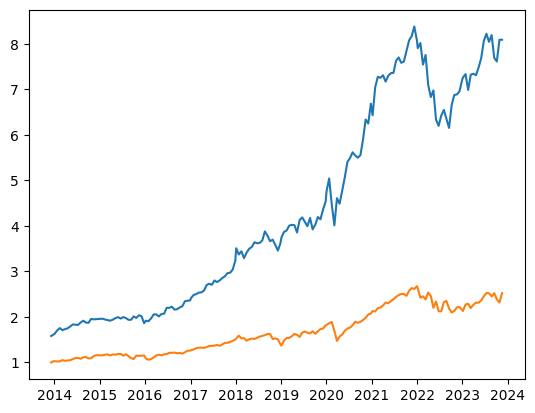

In [35]:
plt.plot(portfolio["date"].values,portfolio["cr"].values)
plt.plot(portfolio["date"].values,portfolio["bcr"].values)
plt.show()

In [36]:
recommendations = trades.sort_values("date").tail(positions)

In [37]:
recommendations

,date,abs,ticker,gics sector,adjclose,return,year,quarter,month,week,weekday
2042,2023-12-07 00:00:00+00:00,0.101538,SPG,Real Estate,131.35,NaN,2023,4,12,49,3
2033,2023-12-07 00:00:00+00:00,0.082222,T,Communication Services,17.09,NaN,2023,4,12,49,3
2034,2023-12-07 00:00:00+00:00,0.179133,GM,Consumer Discretionary,33.51,NaN,2023,4,12,49,3
2035,2023-12-07 00:00:00+00:00,0.096998,KHC,Consumer Staples,36.50,NaN,2023,4,12,49,3
2036,2023-12-07 00:00:00+00:00,-0.011067,CVX,Energy,142.42,NaN,2023,4,12,49,3
2037,2023-12-07 00:00:00+00:00,0.116130,SCHW,Financials,62.96,NaN,2023,4,12,49,3
2038,2023-12-07 00:00:00+00:00,0.073527,ABBV,Health Care,147.97,NaN,2023,4,12,49,3
2039,2023-12-07 00:00:00+00:00,0.131002,BA,Industrials,237.33,NaN,2023,4,12,49,3
2040,2023-12-07 00:00:00+00:00,0.125998,CRM,Information Technology,248.85,NaN,2023,4,12,49,3
2041,2023-12-07 00:00:00+00:00,0.004543,DOW,Materials,51.07,NaN,2023,4,12,49,3


In [38]:
db.connect()
db.drop('portfolios')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",trades)
db.store("recommendations",recommendations)
db.disconnect()